In [39]:
%run general_functions.ipynb

In [40]:
import os
import math
import xesmf as xe

In [43]:
def alk_integral(ds, var):
    earth_radius = 6.371e6 # in m

    # source dataset
    weights = np.cos(np.deg2rad(ds.nav_lat))
    ds_fin = ds.weighted(weights)
    ds_fin = ds_fin.mean(("x", "y"))
    ds_fin = ds_fin[var] * 31536000 * (4 * math.pi * (earth_radius**2)) * 1e-18
    
    return ds_fin

In [57]:
years = list(range(2014,2105,1))
for i in years:
    year = xr.open_dataset(f"/Users/chiaraciscato/Desktop/GEOMAR/2024_ciscato_oae_seasonality/alk_mask/alkalinity_mask_y{i}.nc")
    print(alk_integral(year,'alk_flux'))

<xarray.DataArray 'alk_flux' ()>
array(0.)
<xarray.DataArray 'alk_flux' ()>
array(0.)
<xarray.DataArray 'alk_flux' ()>
array(0.)
<xarray.DataArray 'alk_flux' ()>
array(0.)
<xarray.DataArray 'alk_flux' ()>
array(0.)
<xarray.DataArray 'alk_flux' ()>
array(0.)
<xarray.DataArray 'alk_flux' ()>
array(0.)
<xarray.DataArray 'alk_flux' ()>
array(0.)
<xarray.DataArray 'alk_flux' ()>
array(0.)
<xarray.DataArray 'alk_flux' ()>
array(0.)
<xarray.DataArray 'alk_flux' ()>
array(0.)
<xarray.DataArray 'alk_flux' ()>
array(2.77646526)
<xarray.DataArray 'alk_flux' ()>
array(5.55293051)
<xarray.DataArray 'alk_flux' ()>
array(8.32939577)
<xarray.DataArray 'alk_flux' ()>
array(11.07551714)
<xarray.DataArray 'alk_flux' ()>
array(13.88232628)
<xarray.DataArray 'alk_flux' ()>
array(16.65879153)
<xarray.DataArray 'alk_flux' ()>
array(19.43525679)
<xarray.DataArray 'alk_flux' ()>
array(22.15103428)
<xarray.DataArray 'alk_flux' ()>
array(24.9881873)
<xarray.DataArray 'alk_flux' ()>
array(27.76465255)
<xarray.Dat

In [3]:
input_dir = '/Users/chiaraciscato/Desktop/GEOMAR/2024_ciscato_oae_seasonality/alk_mask/'

files = sorted([os.path.join(input_dir, f) for f in os.listdir(input_dir) if f.endswith('.nc')])

datasets = []

for i, f in enumerate(files):
    ds = xr.open_dataset(f)
    
    ds = ds.expand_dims(dim={'time': [i]})
    
    datasets.append(ds)

combined = xr.concat(datasets, dim='time')

combined['time'] = np.arange(1, len(files)+1) 

In [18]:
n_years = combined.dims['time']
new_time = pd.date_range(start='2014-01-01', periods=n_years, freq='YS')  # 'YS' = Year Start

combined['time'] = new_time

In [4]:
ds_fin = ds_fin['alk_flux'] * 31536000 * (4 * math.pi * (earth_radius**2)) * 1e-18

In [5]:
co2flux_base = xr.open_dataset('/Users/chiaraciscato/Desktop/GEOMAR/2024_ciscato_oae_seasonality/lastDecade/co2flux_base70_lastDecade.nc')
co2flux_oae = xr.open_dataset('/Users/chiaraciscato/Desktop/GEOMAR/2024_ciscato_oae_seasonality/lastDecade/co2flux_oae70_lastDecade.nc')

In [6]:
# ocean mask

mesk_mask = xr.open_dataset('/Users/chiaraciscato/Desktop/GEOMAR/2024_ciscato_oae_seasonality/lastDecade/mesh_mask.nc')
dx, dy = mesk_mask.e1t, mesk_mask.e2t
grid_cell_area = (dx * dy).isel(t=0)

mesk_mask['tmask'] = mesk_mask['tmask'].where(mesk_mask['tmask']!=0)
grid_cell_ocean = (mesk_mask['tmask'].isel(t=0,z=0)*grid_cell_area)
grid_cell_ocean = grid_cell_ocean.where(grid_cell_ocean)

ocean_slice = grid_cell_ocean.sel(x=slice(520, 595), y=slice(330, 435)) # m-2

In [23]:
# alkalkinity mask

alk_mask = combined.where(combined)
alk_mask = alk_mask.sel(x=slice(520, 595), y=slice(330, 435), time=slice('2090','2100'))

alk_mask_nans = xr.where(alk_mask.notnull(), 1, np.nan)
alk_mask_nans = alk_mask_nans.where(alk_mask_nans)
coastline_ocean = (ocean_slice * alk_mask_nans).isel(time=0)

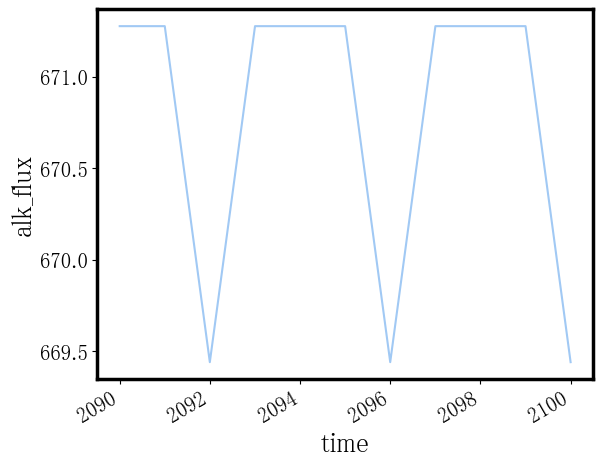

In [35]:
alk_mask['alk_flux'].sum(['x','y']).plot()

In [34]:
((alk_mask * coastline_ocean).sum(['x','y']) * 31536000  * 1e-18).alk_flux.resample(time="AS").sum(dim="time")

<xarray.DataArray 'alk_flux' (time: 11)>
array([24.82577224, 24.82577224, 24.75794226, 24.82577224, 24.82577224,
       24.82577224, 24.75794226, 24.82577224, 24.82577224, 24.82577224,
       24.75794226])
Coordinates:
  * time     (time) datetime64[ns] 2090-01-01 2091-01-01 ... 2100-01-01

In [45]:
alk_mask['alk_flux'] = (alk_mask['alk_flux'] * coastline_ocean['alk_flux']) # mol y-1 

In [46]:
co2flux_change = co2flux_oae - co2flux_base
co2flux_change['co2flux'] = (co2flux_change['co2flux'] * 1000 / 44.009 * 31536000 * ocean_slice).sum(dim=['x','y']) # mol yr-1
co2flux_change = co2flux_change.groupby("time_counter.year").mean("time_counter")

(array([ 4740.,  4740.,     0.,   948.,  8532.,  4740.,   948.,  3792.,
        14220.,  4740.]),
 array([-1.56686985e+13, -1.54019526e+13, -1.51352066e+13, -1.48684607e+13,
        -1.46017147e+13, -1.43349688e+13, -1.40682229e+13, -1.38014769e+13,
        -1.35347310e+13, -1.32679850e+13, -1.30012391e+13]),
 <BarContainer object of 10 artists>)

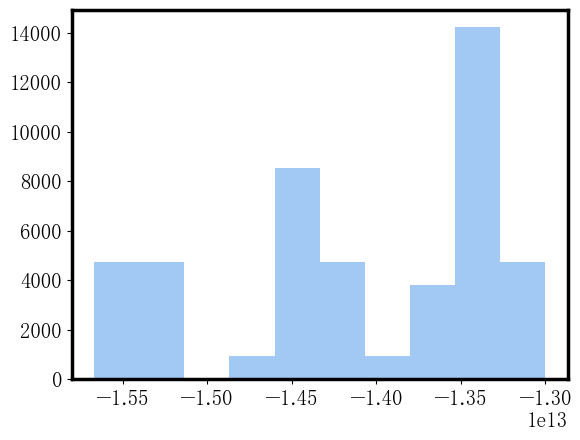

In [48]:
(co2flux_change['co2flux']/alk_mask['alk_flux']).plot()